In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (8,5)

In [3]:
# Titanic 데이터셋 불러오기
df = sns.load_dataset("titanic")

# 데이터 확인
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [5]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


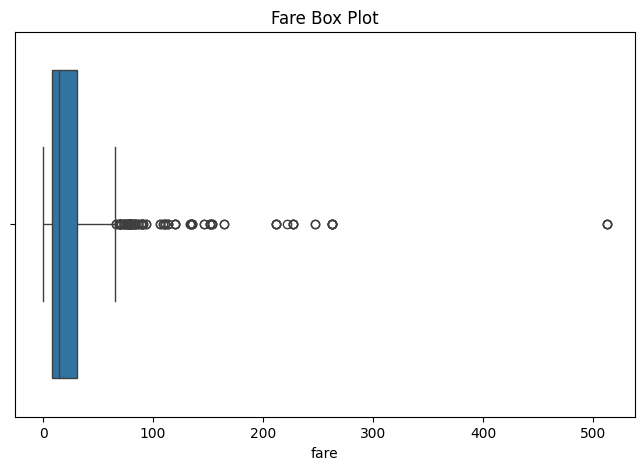

In [6]:
# Fare 컬럼 Box Plot으로 이상치 확인
plt.figure(figsize=(8,5))

sns.boxplot(x=df["fare"])

plt.title("Fare Box Plot")
plt.show()

In [7]:
# IQR 계산
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)

IQR = Q3 - Q1

print(f"Q1 : {Q1}")
print(f"Q3 : {Q3}")
print(f"IQR : {IQR}")

Q1 : 7.9104
Q3 : 31.0
IQR : 23.0896


In [8]:
# 이상치 범위 계산
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print(f"Lower Bound : {lower}")
print(f"Upper Bound : {upper}")

Lower Bound : -26.724
Upper Bound : 65.6344


In [9]:
outliers = df[(df["fare"] < lower) | (df["fare"] > upper)]

print(f"이상치 개수 : {len(outliers)}")

outliers.head()

이상치 개수 : 116


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
27,0,1,male,19.0,3,2,263.0000,S,First,man,True,C,Southampton,no,False
31,1,1,female,NaN,1,0,146.5208,C,First,woman,False,B,Cherbourg,yes,False
34,0,1,male,28.0,1,0,82.1708,C,First,man,True,NaN,Cherbourg,no,False
52,1,1,female,49.0,1,0,76.7292,C,First,woman,False,D,Cherbourg,yes,False


In [10]:
# 이상치 제거
df_clean = df[
    (df["fare"] >= lower) &
    (df["fare"] <= upper)
]

print("원본 데이터 :", len(df))
print("이상치 제거 후 :", len(df_clean))

원본 데이터 : 891
이상치 제거 후 : 775


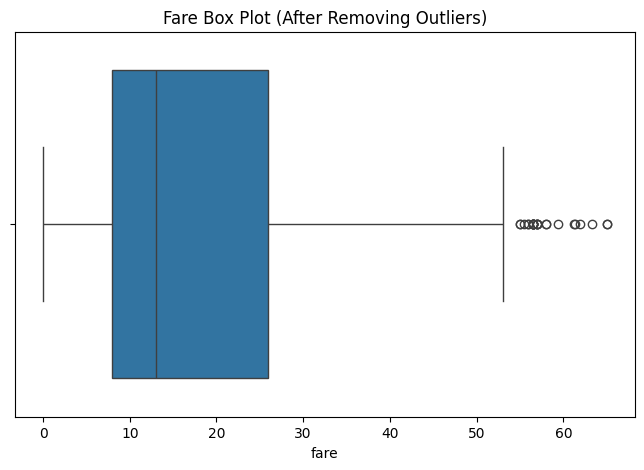

In [11]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df_clean["fare"])

plt.title("Fare Box Plot (After Removing Outliers)")
plt.show()

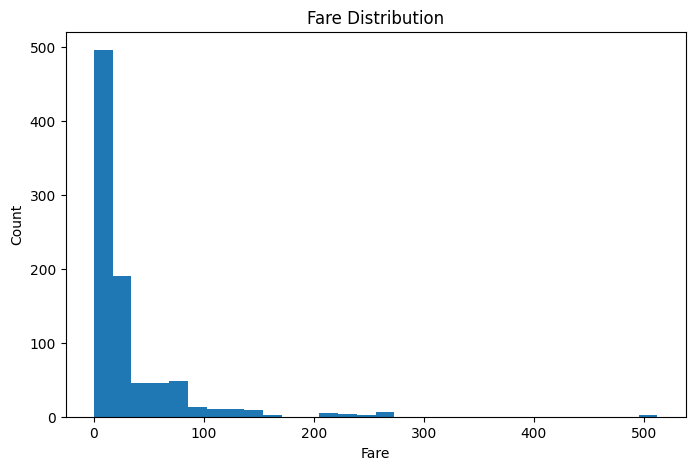

In [12]:
plt.figure(figsize=(8,5))

plt.hist(df["fare"], bins=30)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()

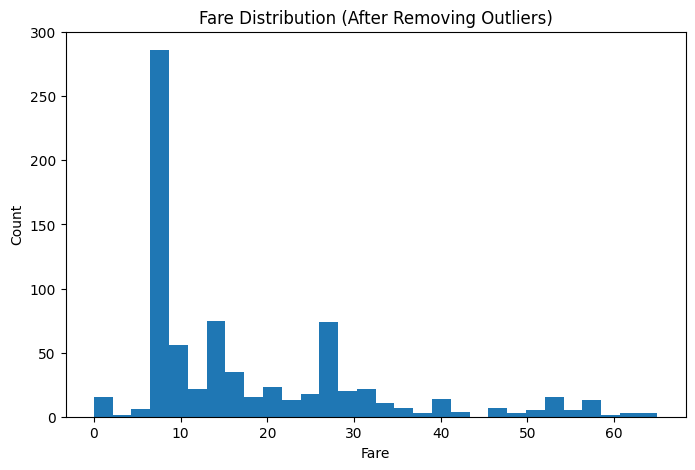

In [13]:
plt.figure(figsize=(8,5))

plt.hist(df_clean["fare"], bins=30)

plt.title("Fare Distribution (After Removing Outliers)")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.show()